In this notebook, we will preprocess the data and build our first model: Random Forest. We will use the undersampling technique to deal with the problem of an imbalance dataset.

In [1]:
# Imports
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# Plotting Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing, model selection
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# Metrics
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_curve, auc
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

In [2]:
# Random_state
SEED = 900

# Load train data
df_train = pd.read_csv('../data/train.csv')
df_train.head(5)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
0,0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,...,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,...,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,...,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,...,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,...,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0


# Data Preprocessing 

### Building undersample

In [3]:
df_train = df_train.sample(frac=1, random_state=SEED) # shuffle dataframe
 # 1st takee all fraud cases
df_fraud = df_train.loc[df_train['IsFraud']==1]
#  2nd take random non fraud cases for the same rows number (they were shuffeled earlier)
df_nonfraud = df_train.loc[df_train['IsFraud']==0].sample(n=len(df_fraud), replace=False, random_state=SEED)

df_balanced_undersample = pd.concat([df_fraud, df_nonfraud]) # concatenate fraud and non fraud parts into one table
df_balanced_undersample = df_balanced_undersample.sample(frac=1, random_state=SEED) # shuffle them again

df_balanced_undersample.head(10)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
100098,100098,60928.0,-0.897890,1.874276,-1.116020,1.390772,0.291276,-1.378878,2.814053,-0.868706,...,-0.166048,0.257070,-0.665098,0.377579,0.585835,-0.431855,-0.116560,-0.412917,258.00,1
31783,31783,37485.0,1.417998,-1.086956,-0.279825,-1.636584,0.770783,3.947293,-1.914212,0.928371,...,0.324217,0.897231,-0.117424,1.058598,0.534360,-0.035893,0.060027,0.019172,3.80,1
110831,110831,63511.0,-1.085466,-0.079586,1.086467,-0.385535,0.835408,-1.359880,0.835119,-0.153056,...,-0.066257,-0.492368,0.157089,0.358560,-0.141470,-0.126745,0.181814,0.104789,83.00,0
139392,139392,71648.0,0.634782,1.449539,-2.174739,1.157711,1.723347,-0.903012,0.845655,0.088712,...,-0.097249,-0.099370,-0.062550,-0.118717,-0.079887,-0.391165,0.160840,-0.092035,3.65,1
137389,137389,71294.0,-1.136520,0.843111,0.294767,-0.659929,0.334478,-0.943287,1.390698,-0.273615,...,0.121768,0.478866,0.163315,-0.096115,-0.023092,-0.456908,0.040915,0.221609,84.90,1
102547,102547,61483.0,1.295881,-0.219947,-0.298484,0.079319,1.405967,3.912896,-1.119966,1.067185,...,-0.120962,-0.346724,-0.007565,1.018905,0.515629,-0.395597,0.072907,0.031692,1.18,1
91355,91355,58284.0,0.983966,-0.164488,0.482868,0.907653,0.013699,1.382706,-0.542607,0.473379,...,-0.090828,0.120772,0.089880,-0.615298,0.135951,0.503848,0.081416,0.037234,29.56,1
86658,86658,56817.0,1.262842,1.268494,-1.923626,1.342786,1.246010,-1.047270,0.616627,-0.154017,...,-0.219795,-0.592129,-0.316088,-0.837673,0.918060,-0.258449,0.058399,0.089912,0.89,1
53755,53755,47712.0,-0.164959,1.482969,-0.407969,1.098987,0.233348,-0.923991,0.534257,0.254767,...,-0.071416,-0.170518,-0.092436,-0.084780,-0.177170,0.440681,-0.020138,0.068231,0.76,0
143088,143088,72574.0,1.141344,-0.270941,0.804715,0.784878,-0.717896,0.273564,-0.619366,0.335837,...,0.071813,0.412066,-0.069001,0.068274,0.407828,0.580076,-0.011258,-0.004515,0.00,0


We have balanced undersample now

C:\Users\tinew\AppData\Local\Temp\ipykernel_35824\106595873.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_train, palette=colors)
C:\Users\tinew\AppData\Local\Temp\ipykernel_35824\106595873.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)


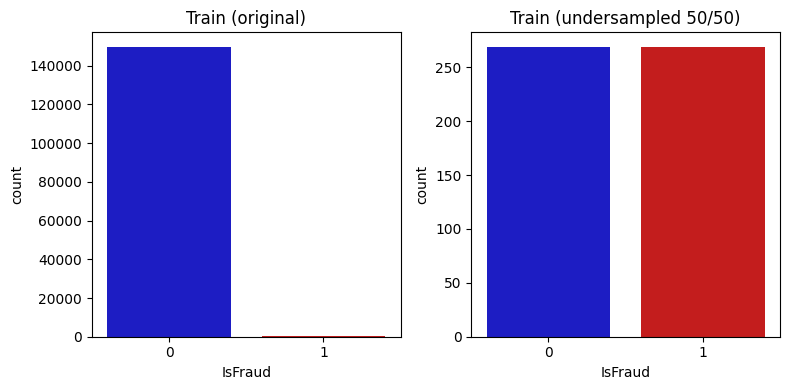

In [4]:
colors = ["#0101DF", "#DF0101"] # Fraud / non Fraud count plot colors

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.countplot(x='IsFraud', data=df_train, palette=colors)
plt.title('Train (original)')

plt.subplot(1,2,2)
sns.countplot(x='IsFraud', data=df_balanced_undersample, palette=colors)
plt.title('Train (undersampled 50/50)')

plt.tight_layout()

Now let's take a look at the correlation matrices for the undersampled and full data frames.

### Feature Scaling

In 01_eda.ipynb we saw that all features are scaled except for the 'Time' and the 'Transaction_Amount'.
To keep the same magnitude for modeling we will perform scalers for both features.
We will use RobustScaler for the 'Transaction_Amount' column as it has outliers and StandardScaler for the 'Time' column. 

After validation experiments we found that dropping 'Time' feature shows better prediction results. Therefore we drop 'Time' column here.

In [5]:
df_train = df_train.drop('Time', axis=1)

In [6]:
# Scaling
rob_scaler = RobustScaler() # RobustScaler is less sensitive to outliers
# stnd_scaler = StandardScaler() # no need, since we dropped the 'Time' column

column_scale = ColumnTransformer(
    transformers= [
        ('robust_scaler', rob_scaler, ['Transaction_Amount']),
        # ('stnd_scaler', stnd_scaler, ['Time']) # no need, since we dropped the 'Time' column
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)

In [7]:
df_train_p = column_scale.fit_transform(df_train)
# return dataframe with original column names
col = column_scale.get_feature_names_out()
df_train_scaled = pd.DataFrame(df_train_p, columns = col, index = df_train.index)
df_train_scaled.head(5)

,Transaction_Amount,id,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,IsFraud
61400,0.373825,61400.0,1.389262,-1.064753,0.629581,-1.297589,-1.562368,-0.785967,-0.873011,-0.190724,...,-0.229534,-0.389836,-0.766599,0.209926,0.426590,0.122734,-0.471567,0.046806,0.033341,0.0
128253,0.370094,128253.0,-2.566170,1.304413,1.153668,0.246528,-0.089935,0.170779,0.270788,0.052671,...,0.320026,-0.135976,0.778813,-0.093200,-0.463687,0.176824,-0.462418,0.009561,-0.037404,0.0
96780,-0.296971,96780.0,-0.066787,0.863023,-0.557522,-0.234837,2.635926,3.168857,0.182744,0.749338,...,0.313869,-0.007040,0.078356,0.029675,1.006687,-0.500161,-0.384946,0.390719,0.235117,0.0
41182,3.478585,41182.0,-1.100581,0.469279,0.498860,0.860759,-0.081327,-0.332999,1.611363,0.013927,...,0.568908,0.302534,0.569074,-0.078171,-0.100845,0.492557,-0.142825,0.281755,0.172338,0.0
108217,-0.275780,108217.0,1.234901,-0.153075,0.002890,-0.184400,0.200143,0.633684,-0.352759,0.245342,...,-0.071109,-0.268895,-0.789837,0.029090,-1.350128,0.091499,0.877045,-0.057747,-0.018836,0.0


In [8]:
df_balanced_undersample_scaled = column_scale.fit_transform(df_balanced_undersample)

col = column_scale.get_feature_names_out()
df_balanced_undersample_scaled = pd.DataFrame(df_balanced_undersample_scaled, columns = col, index = df_balanced_undersample.index)
df_balanced_undersample_scaled.head(5)

,Transaction_Amount,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,...,feat20,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,IsFraud
100098,2.997680,100098.0,60928.0,-0.897890,1.874276,-1.116020,1.390772,0.291276,-1.378878,2.814053,...,-0.095272,-0.166048,0.257070,-0.665098,0.377579,0.585835,-0.431855,-0.116560,-0.412917,1.0
31783,-0.190381,31783.0,37485.0,1.417998,-1.086956,-0.279825,-1.636584,0.770783,3.947293,-1.914212,...,0.190783,0.324217,0.897231,-0.117424,1.058598,0.534360,-0.035893,0.060027,0.019172,1.0
110831,0.802910,110831.0,63511.0,-1.085466,-0.079586,1.086467,-0.385535,0.835408,-1.359880,0.835119,...,0.258947,-0.066257,-0.492368,0.157089,0.358560,-0.141470,-0.126745,0.181814,0.104789,0.0
139392,-0.192262,139392.0,71648.0,0.634782,1.449539,-2.174739,1.157711,1.723347,-0.903012,0.845655,...,0.156561,-0.097249,-0.099370,-0.062550,-0.118717,-0.079887,-0.391165,0.160840,-0.092035,1.0
137389,0.826739,137389.0,71294.0,-1.136520,0.843111,0.294767,-0.659929,0.334478,-0.943287,1.390698,...,-0.381480,0.121768,0.478866,0.163315,-0.096115,-0.023092,-0.456908,0.040915,0.221609,1.0


All the features are scaled now.

Compare the correlation matrices for original vs. undersampled data. Note: that in the original unbalanced data 'IsFraud' is not sensitive for correlations. Therefore we should refer to the undersampled correlation matrix.

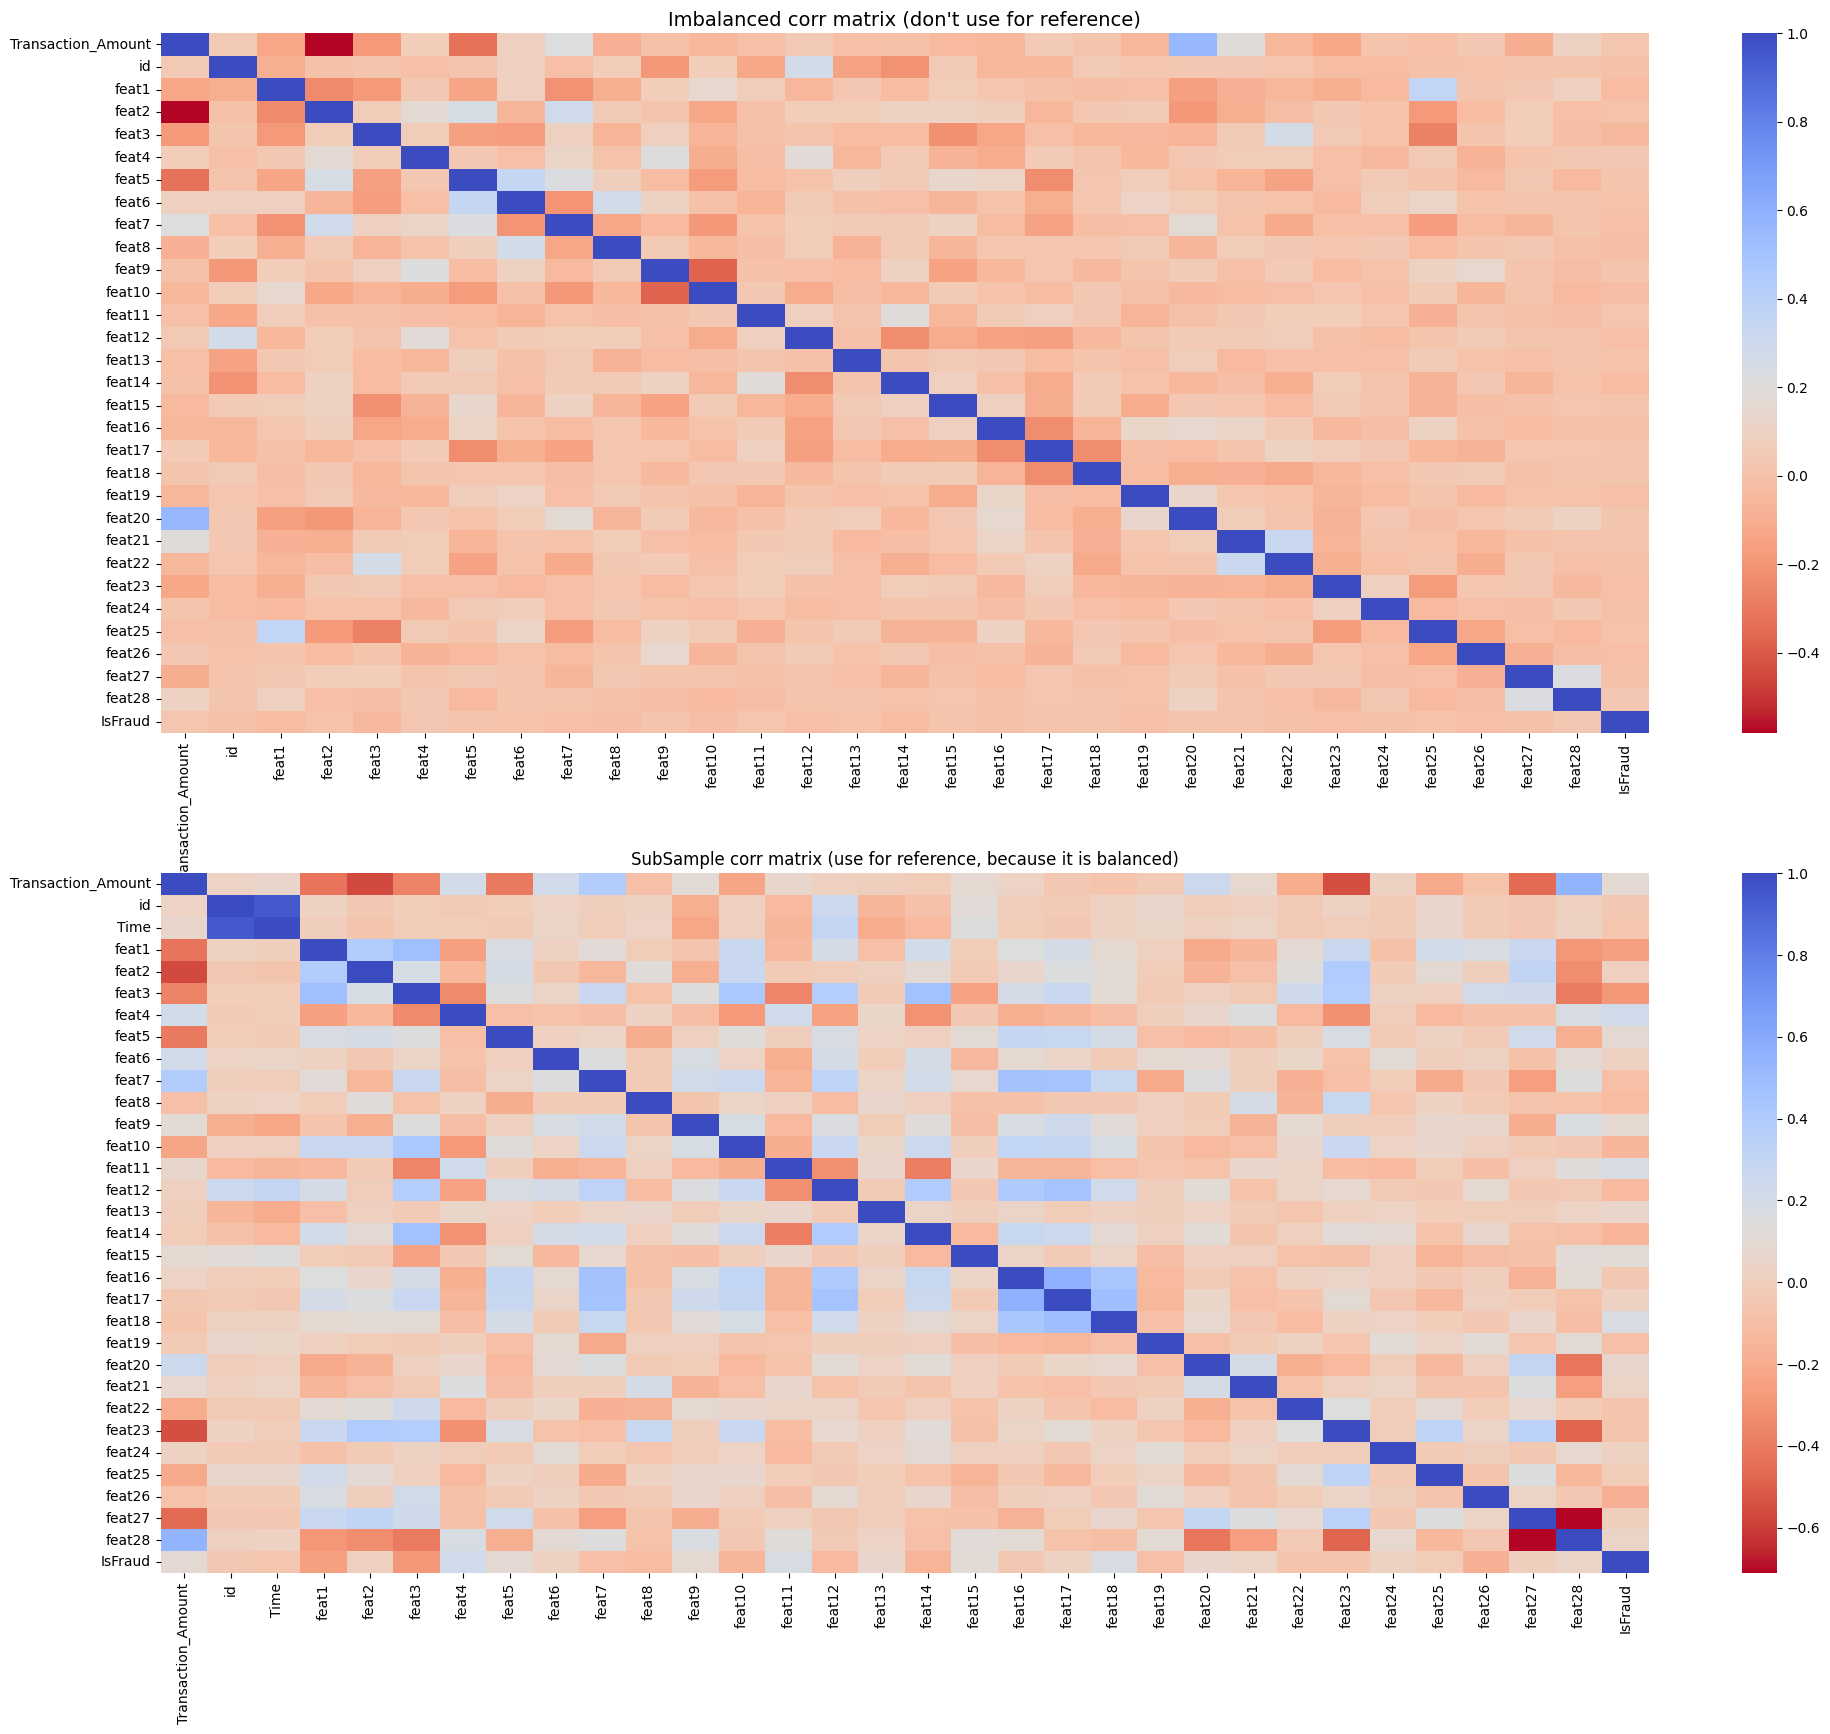

In [9]:
f, (ax1, ax2) = plt.subplots(2,1,figsize=(24,20))

corr = df_train_scaled.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced corr matrix (don't use for reference)", fontsize=14)

sub_sample_corr = df_balanced_undersample_scaled.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title("SubSample corr matrix (use for reference, because it is balanced)")
plt.show()

Correlation matrix of the undersample found correlations for isFraud in comparison with the imbalanced train dataframe. However, we see only a few features that negatively correlate with the 'isFraud' column: feat1, feat3, feat26


C:\Users\tinew\AppData\Local\Temp\ipykernel_35824\439697521.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample_scaled, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_35824\439697521.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample_scaled, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_35824\439697521.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat26', data=df

Text(0.5, 1.0, 'feat19 vs class negative corr')

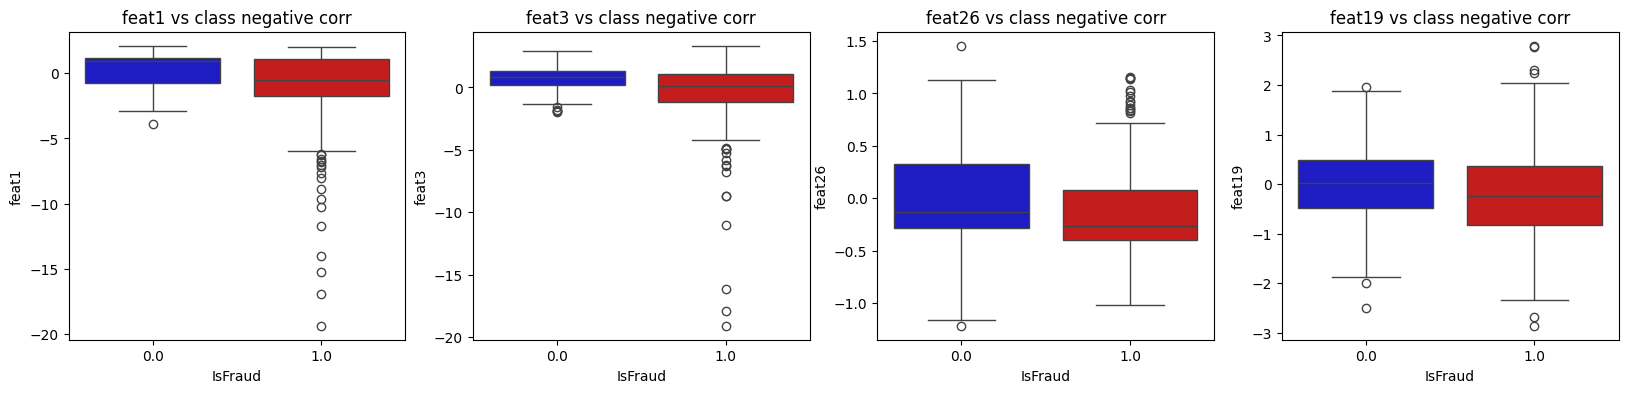

In [10]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat1', data=df_balanced_undersample_scaled, palette=colors, ax=axes[0])
axes[0].set_title('feat1 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat3', data=df_balanced_undersample_scaled, palette=colors, ax=axes[1])
axes[1].set_title('feat3 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat26', data=df_balanced_undersample_scaled, palette=colors, ax=axes[2])
axes[2].set_title('feat26 vs class negative corr')

sns.boxplot(x='IsFraud', y='feat19', data=df_balanced_undersample_scaled, palette=colors, ax=axes[3])
axes[3].set_title('feat19 vs class negative corr')

We see only few features which positive correlates with isFraud column: feat4 , feat11, feat18, feat15


C:\Users\tinew\AppData\Local\Temp\ipykernel_35824\2408817435.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample_scaled, palette=colors, ax=axes[0])
C:\Users\tinew\AppData\Local\Temp\ipykernel_35824\2408817435.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample_scaled, palette=colors, ax=axes[1])
C:\Users\tinew\AppData\Local\Temp\ipykernel_35824\2408817435.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsFraud', y='feat18', dat

Text(0.5, 1.0, 'feat15 vs class positive corr')

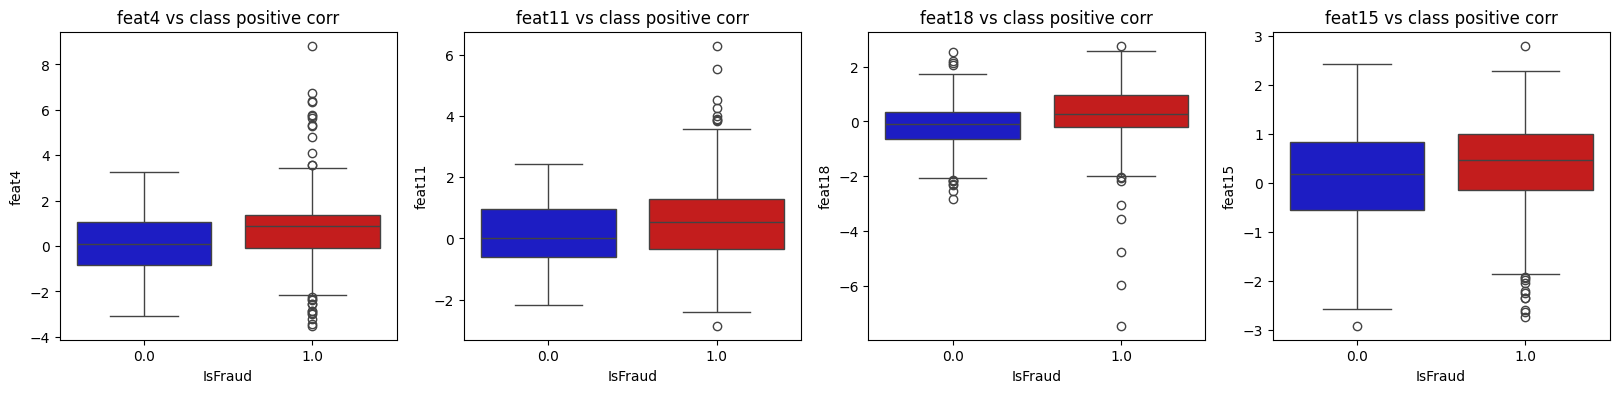

In [11]:
# boxplots for most interested features from the corr matrix
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x='IsFraud', y='feat4', data=df_balanced_undersample_scaled, palette=colors, ax=axes[0])
axes[0].set_title('feat4 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat11', data=df_balanced_undersample_scaled, palette=colors, ax=axes[1])
axes[1].set_title('feat11 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat18', data=df_balanced_undersample_scaled, palette=colors, ax=axes[2])
axes[2].set_title('feat18 vs class positive corr')

sns.boxplot(x='IsFraud', y='feat15', data=df_balanced_undersample_scaled, palette=colors, ax=axes[3])
axes[3].set_title('feat15 vs class positive corr')

We see a small difference in the correlated features, nothing outstanding. Let's take a look at a feature importance from a Mutual Information perspective.

In [12]:
# Split X and y
y_balanced_undersample = df_balanced_undersample_scaled['IsFraud']
X_balanced_undersample = df_balanced_undersample_scaled.drop(columns=['IsFraud','id', 'Time'])

Let's take a look at a feature importance from a mutual Information perspective.

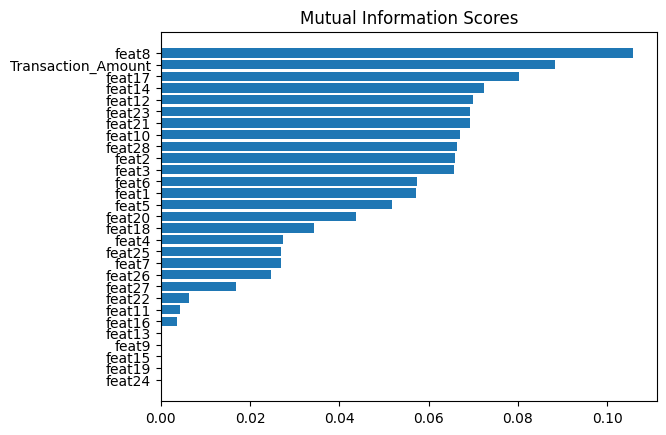

In [13]:
def make_mi_scores(X,y):
    X = X.copy()
    for colname in X.select_dtypes(['object', 'category']):
        x[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_classif(X,y, discrete_features = discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(scores):
    '''Input: pandas series from def make_mi_scores'''
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title('Mutual Information Scores')

mi_scores = make_mi_scores(X_balanced_undersample,y_balanced_undersample)
plot_mi_scores(mi_scores)

That could help us to drop features with low MI scores if we will need it in future, for instance for performance improvements. But now we just use all of them (except 'Time').

# Model comparison

Here we will test and select the best classifier for the balanced undersample. To avoid a data leakage we need to implement the scaling after train-validation (test) split. Thus we do it again now.

Undersampling is applied only to the training pool; validation keeps the same 50/50 ratio as the split from the balanced pool.

In [14]:
X_train, X_valid, y_train, y_valid = train_test_split(X_balanced_undersample, y_balanced_undersample, test_size = 0.2, random_state=SEED)

In [15]:
# Scaling features
X_train_scaled = column_scale.fit_transform(X_train) # output ndarray
X_valid_scaled = column_scale.transform(X_valid) # output ndarray

# Values into arrays for feeding the classification algorithms
y_train = y_train.values
y_valid = y_valid.values

Note: scalers are fit on training data only; validation/test are transformed with the same scaler to avoid leakage.

In [16]:
# Implement simple classifiers
classifiers = {
    "LogisticRegression" : LogisticRegression(random_state=SEED),
    "KNearest" : KNeighborsClassifier(),
    "Support Vector Classifier" : SVC(random_state=SEED),
    "DecisionTreeClassifier" : DecisionTreeClassifier(random_state=SEED),
    "Random Forest" : RandomForestClassifier(random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators = 400, max_depth = 3, learning_rate = 0.01, random_state=SEED
    ),
    "Neural Network" : MLPClassifier(
                                hidden_layer_sizes=(50,50),
                                activation='relu',
                                solver='adam',
                                alpha=1e-3,
                                learning_rate_init=1e-3,
                                early_stopping=True,
                                validation_fraction=0.1,
                                max_iter=500,
                                random_state=SEED
                            )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) # shuffled 5 folds for cross_val_score

for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_valid)
    training_score = cross_val_score(classifier, X_train, y_train, cv=skf)
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "% accuracy score")
print("-------------------------")
for key, classifier in classifiers.items():
    # classifier.fit(X_train, y_valid)
    training_score = cross_val_score(classifier, X_train, y_train, cv=skf, scoring='average_precision')
    print("Classifiers:", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2)*100, "average_precision")

Classifiers: LogisticRegression Has a training score of 73.0 % accuracy score
Classifiers: KNeighborsClassifier Has a training score of 68.0 % accuracy score
Classifiers: SVC Has a training score of 71.0 % accuracy score
Classifiers: DecisionTreeClassifier Has a training score of 68.0 % accuracy score
Classifiers: RandomForestClassifier Has a training score of 74.0 % accuracy score
Classifiers: GradientBoostingClassifier Has a training score of 70.0 % accuracy score
Classifiers: MLPClassifier Has a training score of 68.0 % accuracy score
-------------------------
Classifiers: LogisticRegression Has a training score of 82.0 average_precision
Classifiers: KNeighborsClassifier Has a training score of 72.0 average_precision
Classifiers: SVC Has a training score of 83.0 average_precision
Classifiers: DecisionTreeClassifier Has a training score of 62.0 average_precision
Classifiers: RandomForestClassifier Has a training score of 80.0 average_precision
Classifiers: GradientBoostingClassifier 

We choose the RandomForestClassifier since high level average_precision, accuracy, simplicity and performance.

In [17]:
# fit model
model = RandomForestClassifier(random_state=SEED)
model.fit(X_train,y_train)

# predictions for validation set
preds = model.predict(X_valid)

We report ROC-AUC, PR-AUC, f1 on the validation split.

In [18]:
# Detaiiled precision/recall/F1 by class:
print(classification_report(y_valid, preds))

              precision    recall  f1-score   support

         0.0       0.66      0.73      0.69        52
         1.0       0.72      0.64      0.68        56

    accuracy                           0.69       108
   macro avg       0.69      0.69      0.69       108
weighted avg       0.69      0.69      0.68       108



In [19]:
# 2) ROC AUC for overall separability
probs = model.predict_proba(X_valid)[:,1]
print('ROC AUC:', roc_auc_score(y_valid, probs))
# 3) Precision-Recall AUC (more informative when positives are rare):
precision, recall, _ = precision_recall_curve(y_valid, probs)
print('PR AUC', auc(recall, precision))

ROC AUC: 0.7455357142857143
PR AUC 0.7517976455320545


<function matplotlib.pyplot.show(close=None, block=None)>

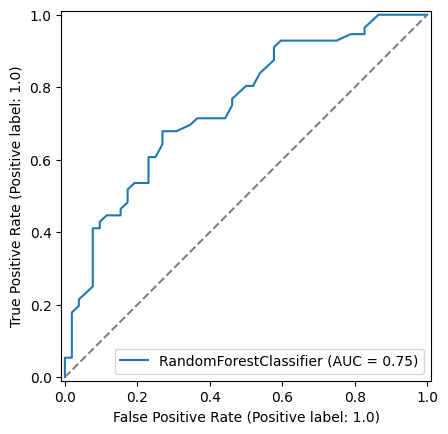

In [20]:
disp = RocCurveDisplay.from_estimator(
    model, X_valid, y_valid
)
plt.plot([0,1],[0,1],'--',color='gray')
plt.show

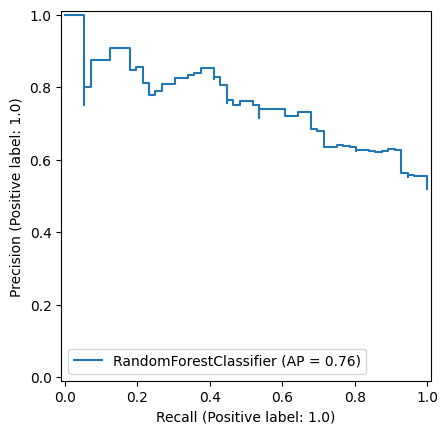

In [21]:
disp2 = PrecisionRecallDisplay.from_estimator(
    model, X_valid, y_valid,
)
plt.show()

# Submission for Kaggle

We use our model to make predictions based on the test data from the Kaggle competition Credit Card Fraud Detection (the link: https://www.kaggle.com/competitions/credit-card-fraud-prediction/)


In [22]:
test_df = pd.read_csv('../data/test.csv')
submission_data = test_df.drop(['id','Time'], axis=1)
submission_data = column_scale.transform(submission_data) # Scaling Time and amount values.
preds_for_submission = model.predict_proba(submission_data) # Get predictions

output = pd.DataFrame(
    {
        'id' : test_df.id,
        'IsFraud' : preds_for_submission[:,1]
    }
)
output.to_csv('submission.csv', index=False)
output.head()

c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,id,IsFraud
0,150000,0.39
1,150001,0.43
2,150002,0.62
3,150003,0.41
4,150004,0.60


Firstly, we got 0.68747 for the Private Score and 0.77137 for the Public Score.

Then, we dropped Time feature and got improved results: 0.70195 Private Score and 0.77137 for the Public Score.

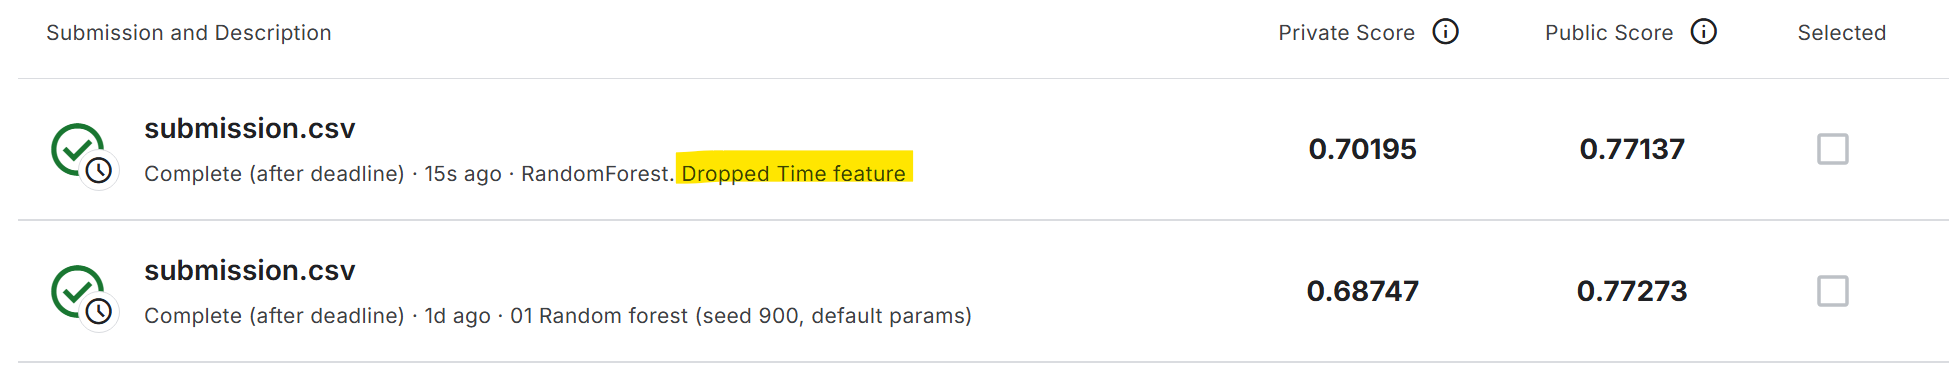
